### Piotr Przymus 127902
# Laboratorium 4: regresja wieloraka

In [2]:
# 1. Wczytanie danych
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)
df.columns = [
    'RelativeCompactness', 'SurfaceArea', 'WallArea', 'RoofArea',
    'OverallHeight', 'Orientation', 'GlazingArea',
    'GlazingAreaDistribution',
    'HeatingLoad', 'CoolingLoad'
]
print(df.head())

   RelativeCompactness  SurfaceArea  WallArea  RoofArea  OverallHeight  \
0                 0.98        514.5     294.0    110.25            7.0   
1                 0.98        514.5     294.0    110.25            7.0   
2                 0.98        514.5     294.0    110.25            7.0   
3                 0.98        514.5     294.0    110.25            7.0   
4                 0.90        563.5     318.5    122.50            7.0   

   Orientation  GlazingArea  GlazingAreaDistribution  HeatingLoad  CoolingLoad  
0            2          0.0                        0        15.55        21.33  
1            3          0.0                        0        15.55        21.33  
2            4          0.0                        0        15.55        21.33  
3            5          0.0                        0        15.55        21.33  
4            2          0.0                        0        20.84        28.28  


In [3]:
# 2. Budowa modelu regresji wielorakiej (dla HeatingLoad)
import statsmodels.api as sm
X = df[['RelativeCompactness', 'SurfaceArea', 'WallArea', 'RoofArea',
        'OverallHeight', 'Orientation', 'GlazingArea', 'GlazingAreaDistribution']]
y = df['HeatingLoad']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            HeatingLoad   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     1187.
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        17:06:00   Log-Likelihood:                -1912.5
No. Observations:                 768   AIC:                             3841.
Df Residuals:                     760   BIC:                             3878.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

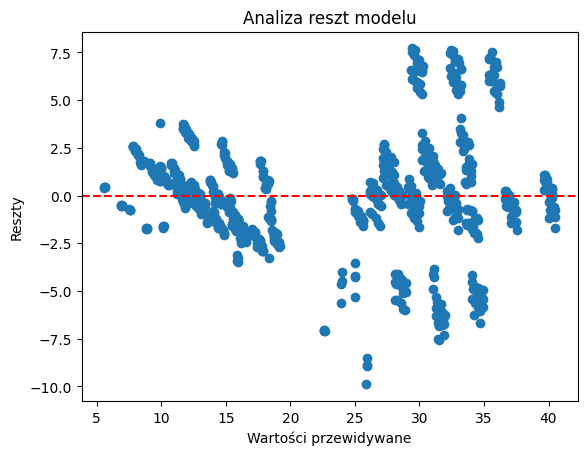

In [4]:
# 3. Ocena dopasowania modelu i analiza reszt
import matplotlib.pyplot as plt
y_pred = model.predict(X)
residuals = y - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Wartości przewidywane")
plt.ylabel("Reszty")
plt.title("Analiza reszt modelu")
plt.show()

### 1. Co oznacza wysoka wartość współczynnika R²?
Wysoka wartość współczynnika R² oznacza, że model dobrze wyjaśnia zmienność danych. Innymi słowy, zmienne niezależne dobrze opisują zmienną zależną (Heating Load).
Na przykład R² = 0.90 oznacza, że 90% zmienności zapotrzebowania na ogrzewanie jest wyjaśniane przez model regresji.
### 2. Jak interpretować ujemny współczynnik przy zmiennej `RelativeCompactness`?
Ujemny współczynnik oznacza, że wraz ze wzrostem wartości `RelativeCompactness` przewidywana wartość `Heating Load` maleje.
Może to sugerować, że bardziej zwarte budynki tracą mniej ciepła i potrzebują mniej energii do ogrzewania.
### 3. Dlaczego warto analizować reszty modelu?
Analiza reszt pozwala sprawdzić, czy model regresji został poprawnie dopasowany do danych.
Dzięki resztom można wykryć:
- błędy modelu,
- obserwacje odstające,
- nieliniowości,
- problemy z założeniami regresji (np. nierówną wariancję błędów).

Jeżeli reszty są losowo rozłożone wokół zera, oznacza to, że model działa poprawnie.
### 4. W jaki sposób można rozszerzyć analizę, aby objąć zmienną Cooling Load?
Aby objąć analizą zmienną Cooling Load, należy zbudować drugi model regresji, w którym zmienną zależną będzie CoolingLoad zamiast HeatingLoad.
```
y = df['CoolingLoad']
model = sm.OLS(y, X).fit()
print(model.summary())
```
Następnie można porównać oba modele i sprawdzić, które cechy budynku bardziej wpływają na ogrzewanie, a które na chłodzenie.
### 5. Jakie ograniczenia ma model regresji wielorakiej w tym przypadku?
Model regresji wielorakiej ma kilka ograniczeń:
- zakłada liniową zależność między zmiennymi,
- może być wrażliwy na obserwacje odstające,
- nie uwzględnia bardziej złożonych zależności nieliniowych,
- zmienne kategoryczne mogą wymagać dodatkowego kodowania,
- wysoka korelacja między zmiennymi niezależnymi (współliniowość) może pogarszać interpretację współczynników.

Dodatkowo model może nie uwzględniać wszystkich czynników wpływających na efektywność energetyczną budynków.